In [ ]:
# 1) Environment and Imports
%pip install keras
import os, sys, json, time, random
from pathlib import Path
import numpy as np
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

print("Python:", sys.version)
print("TF:", tf.__version__)
print("Built with CUDA:", tf.test.is_built_with_cuda())
print("GPUs:", tf.config.list_physical_devices('GPU'))

# Ensure TensorFlow uses GPU if available

Python: 3.12.11 (main, Jun  4 2025, 08:56:18) [GCC 11.4.0]
TF: 2.19.0
Built with CUDA: True
GPUs: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [ ]:
# Upload the zip via a picker
from google.colab import files
up = files.upload()  # choose english_2split_case.zip

# Unzip to /content
import zipfile, io, os
zip_name = next(k for k in up.keys() if k.endswith('.zip'))
with zipfile.ZipFile(io.BytesIO(up[zip_name])) as zf:
    zf.extractall('/content')

# If the zip contains a top-level folder, make sure its name is english_2split_case
!ls -la /content


Saving english_2split_case.zip to english_2split_case (2).zip
total 41004
drwxr-xr-x 1 root root     4096 Sep  3 08:50  .
drwxr-xr-x 1 root root     4096 Sep  3 08:39  ..
drwxr-xr-x 2 root root     4096 Sep  3 08:44  artifacts
drwxr-xr-x 4 root root     4096 Aug 29 13:42  .config
drwxr-xr-x 4 root root     4096 Sep  3 08:43  english_2split_case
-rw-r--r-- 1 root root 13984308 Sep  3 08:47 'english_2split_case (1).zip'
-rw-r--r-- 1 root root 13984308 Sep  3 08:50 'english_2split_case (2).zip'
-rw-r--r-- 1 root root 13984308 Sep  3 08:43  english_2split_case.zip
drwxr-xr-x 1 root root     4096 Aug 29 13:43  sample_data


In [ ]:
# 2) Configuration
# Change this to your dataset root that contains: train/ and test/
try:
    HERE = Path(__file__).parent
except NameError:
    HERE = Path.cwd()
DATA_ROOT = HERE / "english_2split_case"
TRAIN_DIR = DATA_ROOT / "train"
TEST_DIR  = DATA_ROOT / "test"

# Image + training hyperparameters
IMAGE_SIZE = (28, 28)      # 28x28 baseline per design
COLOR_MODE = "grayscale"     # change to "rgb" if needed
BATCH_SIZE = 64
VAL_SPLIT  = 0.1             # 10% of train for validation
SEED       = 1337
EPOCHS     = 20

# Output folder (next to the notebook/script)
ART_DIR = HERE / "artifacts"
ART_DIR.mkdir(parents=True, exist_ok=True)

# Ensure the paths are correct
print("DATA_ROOT:", DATA_ROOT.resolve())
print("Train dir exists:", TRAIN_DIR.exists())
print("Test  dir exists:", TEST_DIR.exists())


DATA_ROOT: /content/english_2split_case
Train dir exists: True
Test  dir exists: True


In [ ]:
# 3) Load Datasets (CASE-SENSITIVE labels)
# image_dataset_from_directory preserves subfolder names exactly as class names (case-sensitive).
# We explicitly do not lower() the labels.
assert TRAIN_DIR.exists(), f"Train folder not found: {TRAIN_DIR}"
assert TEST_DIR.exists(),  f"Test folder not found: {TEST_DIR}"

train_ds = tf.keras.utils.image_dataset_from_directory(
    TRAIN_DIR,
    labels="inferred",
    label_mode="int",
    class_names=None,        # infer from subfolders; KEEP original case
    color_mode=COLOR_MODE,
    batch_size=BATCH_SIZE,
    image_size=IMAGE_SIZE,
    shuffle=True,
    seed=SEED,
    validation_split=VAL_SPLIT,
    subset="training"
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    TRAIN_DIR,
    labels="inferred",
    label_mode="int",
    class_names=None,        # same inference
    color_mode=COLOR_MODE,
    batch_size=BATCH_SIZE,
    image_size=IMAGE_SIZE,
    shuffle=True,
    seed=SEED,
    validation_split=VAL_SPLIT,
    subset="validation"
)

test_ds = tf.keras.utils.image_dataset_from_directory(
    TEST_DIR,
    labels="inferred",
    label_mode="int",
    class_names=None,        # infer from test/ subfolders
    color_mode=COLOR_MODE,
    batch_size=BATCH_SIZE,
    image_size=IMAGE_SIZE,
    shuffle=False
)

class_names = train_ds.class_names
print("Class names (case-sensitive):", class_names)
print("Num classes:", len(class_names))

# Safety check: ensure no case-collisions if lowercased
lower_map = {}
dup = []
for c in class_names:
    cl = c.lower()
    if cl in lower_map and lower_map[cl] != c:
        dup.append((lower_map[cl], c))
    else:
        lower_map[cl] = c

if dup:
    print("WARNING: These labels would collide if lowercased (good that we are case-sensitive):", dup)
else:
    print("No case-collisions when lowercased (still training case-sensitively).")


Found 2728 files belonging to 62 classes.
Using 2456 files for training.
Found 2728 files belonging to 62 classes.
Using 272 files for validation.
Found 682 files belonging to 62 classes.
Class names (case-sensitive): ['0', '1', '2', '3', '4', '5', '6', '7', '8', '9', 'L_a', 'L_b', 'L_c', 'L_d', 'L_e', 'L_f', 'L_g', 'L_h', 'L_i', 'L_j', 'L_k', 'L_l', 'L_m', 'L_n', 'L_o', 'L_p', 'L_q', 'L_r', 'L_s', 'L_t', 'L_u', 'L_v', 'L_w', 'L_x', 'L_y', 'L_z', 'U_A', 'U_B', 'U_C', 'U_D', 'U_E', 'U_F', 'U_G', 'U_H', 'U_I', 'U_J', 'U_K', 'U_L', 'U_M', 'U_N', 'U_O', 'U_P', 'U_Q', 'U_R', 'U_S', 'U_T', 'U_U', 'U_V', 'U_W', 'U_X', 'U_Y', 'U_Z']
Num classes: 62
No case-collisions when lowercased (still training case-sensitively).


In [ ]:
# 4) Pipeline performance: cache + prefetch
AUTOTUNE = tf.data.AUTOTUNE
train_ds = train_ds.cache().prefetch(buffer_size=AUTOTUNE)
val_ds   = val_ds.cache().prefetch(buffer_size=AUTOTUNE)
test_ds  = test_ds.cache().prefetch(buffer_size=AUTOTUNE)


In [ ]:
# Data augmentation layers: random flip, rotation and zoom
augment = keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.05),
    layers.RandomZoom(0.1)
])

def make_model(input_shape=(IMAGE_SIZE[0], IMAGE_SIZE[1], 1), num_classes=10):
    """
    Create a simple CNN baseline for handwritten character recognition.

    The architecture consists of three convolutional blocks with ReLU activations and max pooling,
    followed by a fully connected layer.

    Args:
        input_shape: A tuple specifying the input image shape (height, width, channels).
        num_classes: Number of output classes.

    Returns:
        A tf.keras.Model instance.
    """
    inputs = keras.Input(shape=input_shape)
    # Normalize pixel values to [0, 1]
    x = layers.Rescaling(1./255)(inputs)
    # Apply data augmentation
    x = augment(x)
    # Convolutional block 1
    x = layers.Conv2D(32, 3, padding="same", activation="relu")(x)
    x = layers.MaxPooling2D()(x)
    # Convolutional block 2
    x = layers.Conv2D(64, 3, padding="same", activation="relu")(x)
    x = layers.MaxPooling2D()(x)
    # Convolutional block 3
    x = layers.Conv2D(128, 3, padding="same", activation="relu")(x)
    x = layers.MaxPooling2D()(x)
    x = layers.Flatten()(x)
    # Dropout for regularization
    x = layers.Dropout(0.3)(x)
    x = layers.Dense(128, activation="relu")(x)
    outputs = layers.Dense(num_classes, activation="softmax")(x)
    model = keras.Model(inputs, outputs, name="cnn_baseline")
    return model

# Determine input channels based on color mode
num_classes = len(class_names)
in_ch = 1 if COLOR_MODE == "grayscale" else 3
model = make_model(input_shape=(IMAGE_SIZE[0], IMAGE_SIZE[1], in_ch), num_classes=num_classes)
model.summary()

Model: "cnn_baseline"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_4 (InputLayer)      │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling_2 (Rescaling)         │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential_2 (Sequential)       │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 14, 14, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 7, 7, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_8 (MaxPooling2D)  │ (None, 3, 3, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 1152)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 1152)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 128)            │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 62)             │         7,998 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 248,254 (969.74 KB)

 Trainable params: 248,254 (969.74 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# 6) Compile + Callbacks
lr = 1e-3
opt = keras.optimizers.Adam(learning_rate=lr)
model.compile(optimizer=opt, loss="sparse_categorical_crossentropy", metrics=["accuracy"])

ckpt_path = ART_DIR / "cnn_baseline_best.keras"
callbacks = [
    keras.callbacks.ModelCheckpoint(filepath=str(ckpt_path), save_best_only=True, monitor="val_accuracy", mode="max"),
    keras.callbacks.EarlyStopping(patience=5, restore_best_weights=True, monitor="val_accuracy")
]

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS,
    verbose=1,
    callbacks=callbacks
)


Epoch 1/20
39/39 ━━━━━━━━━━━━━━━━━━━━ 5s 71ms/step - accuracy: 0.0169 - loss: 4.1339 - val_accuracy: 0.0037 - val_loss: 4.1285
Epoch 2/20
39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.0122 - loss: 4.1270 - val_accuracy: 0.0037 - val_loss: 4.1278
Epoch 3/20
39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.0264 - loss: 4.1185 - val_accuracy: 0.0037 - val_loss: 4.0667
Epoch 4/20
39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.0517 - loss: 3.9380 - val_accuracy: 0.0368 - val_loss: 3.8553
Epoch 5/20
39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.0990 - loss: 3.5170 - val_accuracy: 0.1029 - val_loss: 3.3468
Epoch 6/20
39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.1601 - loss: 3.1790 - val_accuracy: 0.1765 - val_loss: 3.0146
Epoch 7/20
39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.2017 - loss: 2.8969 - val_accuracy: 0.2353 - val_loss: 2.6384
Epoch 8/20
39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.2755 - loss: 2.5929 - val_accuracy: 0.3088 - val_loss

In [ ]:
# 7) Evaluate on Test Set
test_metrics = model.evaluate(test_ds, verbose=1)
metrics_dict = {k: float(v) for k, v in zip(model.metrics_names, test_metrics)}
print("Test metrics:", metrics_dict)

with open(ART_DIR / "test_metrics.json", "w") as f:
    json.dump(metrics_dict, f, indent=2)


11/11 ━━━━━━━━━━━━━━━━━━━━ 1s 57ms/step - accuracy: 0.4687 - loss: 1.7147
Test metrics: {'loss': 1.508205771446228, 'compile_metrics': 0.5483871102333069}


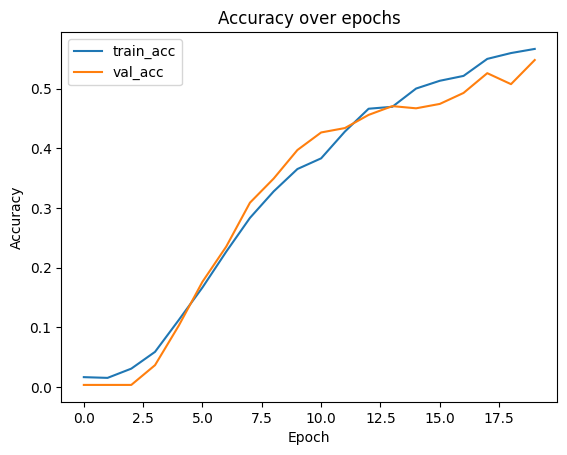

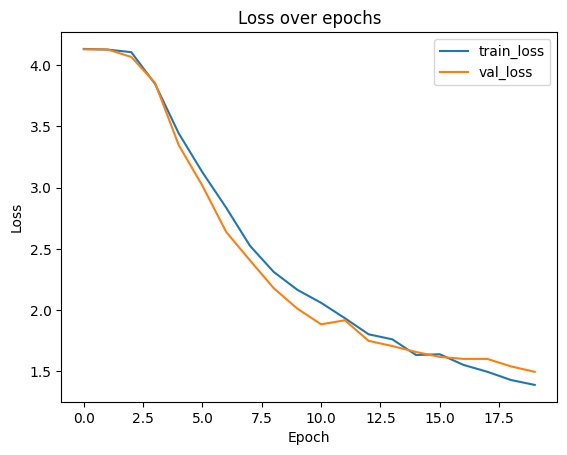

In [ ]:
# 8) Plot learning curves
import matplotlib.pyplot as plt

hist = history.history
plt.figure()
plt.plot(hist.get("accuracy", []), label="train_acc")
plt.plot(hist.get("val_accuracy", []), label="val_acc")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.title("Accuracy over epochs")
plt.savefig(ART_DIR / "acc.png", dpi=150)
plt.show()

plt.figure()
plt.plot(hist.get("loss", []), label="train_loss")
plt.plot(hist.get("val_loss", []), label="val_loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.title("Loss over epochs")
plt.savefig(ART_DIR / "loss.png", dpi=150)
plt.show()


In [ ]:
# 10) Save final model
final_path = ART_DIR / "cnn_baseline_final.keras"
model.save(final_path)
print("Saved best checkpoint to:", ckpt_path.resolve())
print("Saved final model to:", final_path.resolve())


Saved best checkpoint to: /content/artifacts/cnn_baseline_best.keras
Saved final model to: /content/artifacts/cnn_baseline_final.keras



## Notes
- Labels are inferred from subfolder names and kept **case-sensitive**.
- Adjust `IMAGE_SIZE`, `BATCH_SIZE`, and `EPOCHS` to fit your GPU/CPU.
- For a fair baseline, avoid heavy augmentation or architecture tricks here.
- If your images are RGB, set `COLOR_MODE = "rgb"` and update the input channels accordingly.


Stored 682 test samples for visualization.


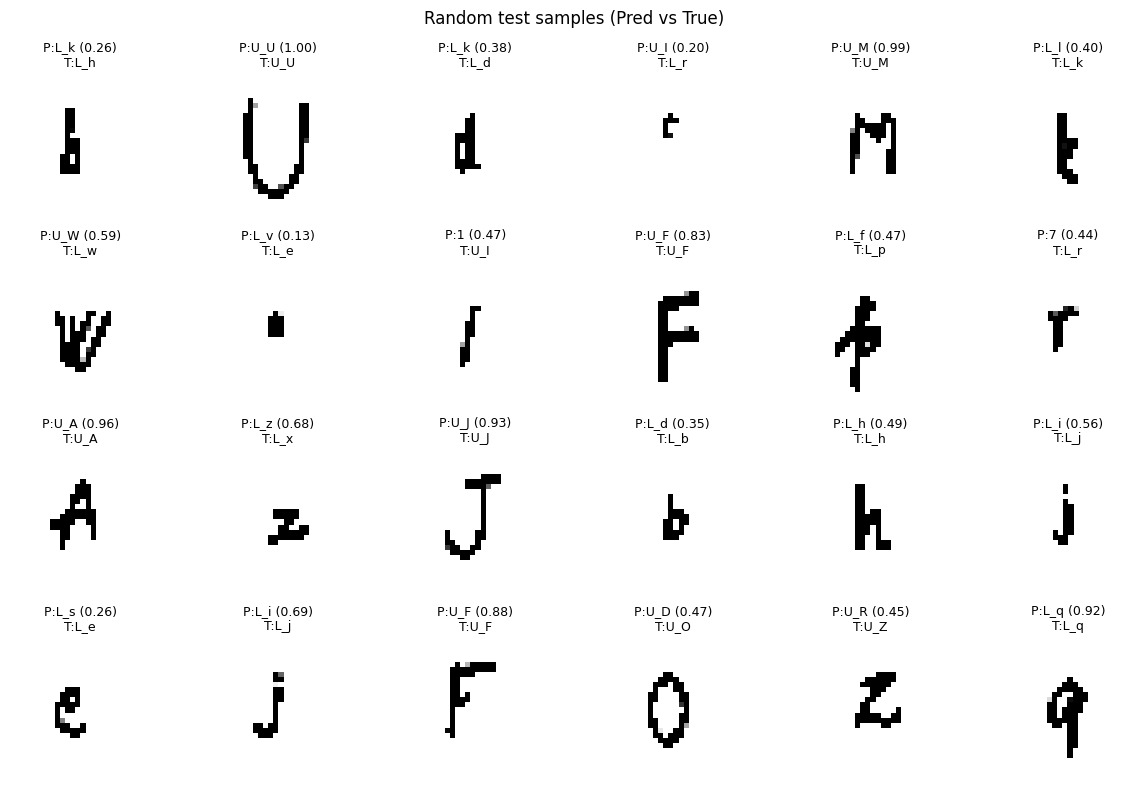

Misclassified: 308 / 682


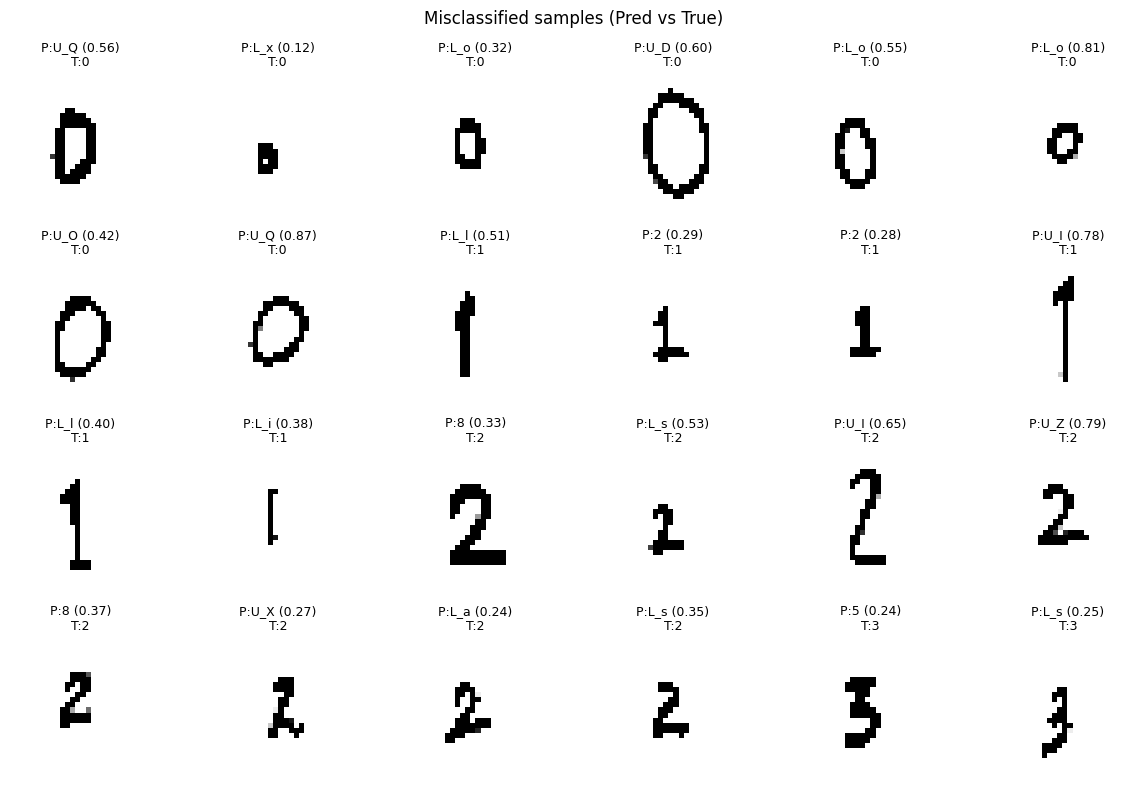

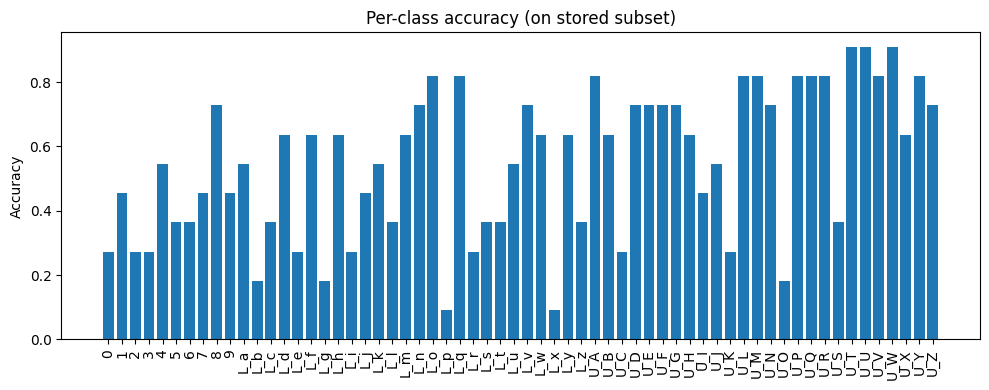

/usr/local/lib/python3.12/dist-packages/keras/src/models/functional.py:241: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: [['keras_tensor_34']]
Received: inputs=Tensor(shape=(1, 28, 28, 1))
  warnings.warn(msg)


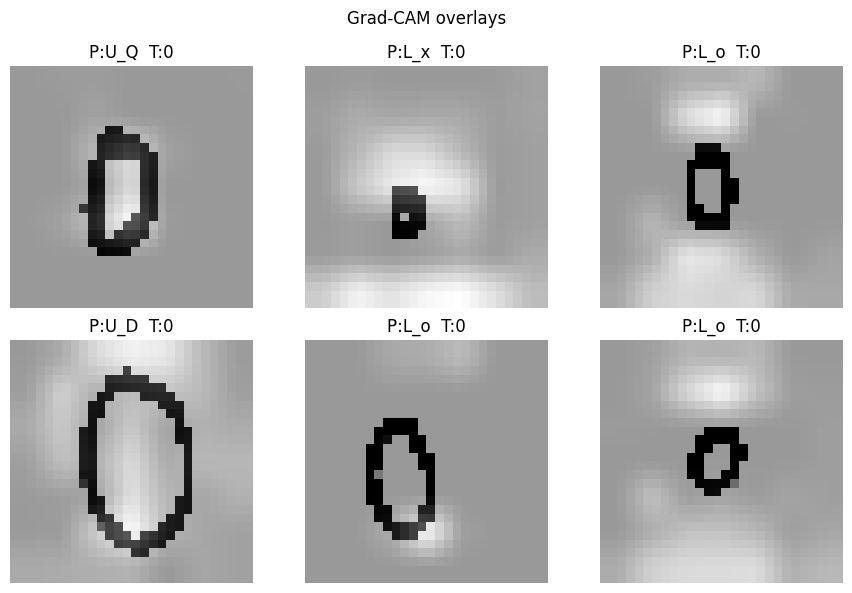

In [ ]:
# Visual Result Checks
# Random test grid, misclassified grid, per-class accuracy bar chart,
# confusion matrix, and optional Grad-CAM overlays.

import math, random
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from sklearn.metrics import confusion_matrix

# Try to get class_names if not already in scope
try:
    class_names  # noqa: F401
except NameError:
    try:
        class_names = test_ds.class_names
    except Exception:
        # fallback to numeric labels if unavailable
        num_out = int(model.output_shape[-1])
        class_names = [str(i) for i in range(num_out)]

# ---- 1) Collect predictions (cap to avoid huge memory use) ----
MAX_STORE = 5000
images, y_true, y_pred, y_prob = [], [], [], []

for batch_imgs, batch_labels in test_ds:
    preds = model.predict(batch_imgs, verbose=0)
    p_idx = np.argmax(preds, axis=1)
    p_prob = np.max(preds, axis=1)

    images.extend(batch_imgs.numpy())
    y_true.extend(batch_labels.numpy().tolist())
    y_pred.extend(p_idx.tolist())
    y_prob.extend(p_prob.tolist())

    if len(images) >= MAX_STORE:
        break

images = np.array(images)
y_true = np.array(y_true)
y_pred = np.array(y_pred)
y_prob = np.array(y_prob)

print(f"Stored {len(images)} test samples for visualization.")

# ---- 2) Helper: show a grid of images with Pred vs True ----
def _show_grid(ids, cols=6, title=""):
    rows = max(1, math.ceil(len(ids) / cols))
    plt.figure(figsize=(cols * 2, rows * 2))
    for i, idx in enumerate(ids[: cols * rows]):
        plt.subplot(rows, cols, i + 1)
        img = images[idx]
        if img.ndim == 3 and img.shape[-1] == 1:
            plt.imshow(img.squeeze(), cmap="gray")
        else:
            plt.imshow(img.astype("uint8"))
        t = y_true[idx]
        p = y_pred[idx]
        prob = y_prob[idx]
        plt.title(f"P:{class_names[p]} ({prob:.2f})\nT:{class_names[t]}", fontsize=9)
        plt.axis("off")
    plt.suptitle(title)
    plt.tight_layout()
    plt.show()

# ---- 3) Random sample grid ----
N = min(24, len(images))
rand_ids = random.sample(range(len(images)), N) if len(images) >= N else list(range(len(images)))
_show_grid(rand_ids, cols=6, title="Random test samples (Pred vs True)")

# ---- 4) Misclassified samples grid ----
wrong_idx = np.nonzero(y_pred != y_true)[0]
print(f"Misclassified: {len(wrong_idx)} / {len(images)}")
if len(wrong_idx) > 0:
    _show_grid(list(wrong_idx[:24]), cols=6, title="Misclassified samples (Pred vs True)")

# ---- 5) Per-class accuracy bar chart ----
num_classes = len(class_names)
totals = np.zeros(num_classes, dtype=int)
correct = np.zeros(num_classes, dtype=int)
for t, p in zip(y_true, y_pred):
    totals[t] += 1
    if t == p:
        correct[t] += 1

acc = np.divide(correct, np.maximum(totals, 1))
plt.figure(figsize=(10, 4))
plt.bar(np.arange(num_classes), acc)
plt.xticks(np.arange(num_classes), class_names, rotation=90)
plt.ylabel("Accuracy")
plt.title("Per-class accuracy (on stored subset)")
plt.tight_layout()
plt.show()

# ---- 7) Optional Grad-CAM overlays (for ConvNets) ----
def _last_conv(model_):
    last = None
    for layer in model_.layers:
        if isinstance(layer, tf.keras.layers.Conv2D):
            last = layer
    return last

def _gradcam(img, model_, last_conv_layer):
    x = img[np.newaxis, ...].astype("float32")
    grad_model = tf.keras.Model([model_.inputs], [last_conv_layer.output, model_.output])
    with tf.GradientTape() as tape:
        conv_out, preds = grad_model(x, training=False)
        idx = tf.argmax(preds[0])
        loss = preds[:, idx]
    grads = tape.gradient(loss, conv_out)
    pooled = tf.reduce_mean(grads, axis=(0, 1, 2))
    conv_out = conv_out[0]
    heat = tf.reduce_sum(tf.multiply(pooled, conv_out), axis=-1)
    heat = tf.maximum(heat, 0) / (tf.reduce_max(heat) + 1e-8)
    heat = tf.image.resize(heat[..., tf.newaxis], (img.shape[0], img.shape[1]))[..., 0].numpy()
    return heat, int(idx.numpy())

last_conv = _last_conv(model)
if last_conv is None:
    print("Grad-CAM skipped (no Conv2D layer found).")
else:
    pick = list(wrong_idx[:6]) if len(wrong_idx) > 0 else list(range(min(6, len(images))))
    rows = max(1, math.ceil(len(pick) / 3))
    cols = 3
    plt.figure(figsize=(cols * 3, rows * 3))
    for k, idx in enumerate(pick):
        img = images[idx]
        heat, _ = _gradcam(img, model, last_conv)

        # Normalize base image to 0..1 and overlay heatmap in grayscale
        if img.ndim == 3 and img.shape[-1] == 1:
            base = np.stack([img.squeeze(), img.squeeze(), img.squeeze()], axis=-1)
        else:
            base = img
        base = base.astype("float32")
        base = (base - base.min()) / (base.max() - base.min() + 1e-8)

        overlay = 0.6 * base + 0.4 * np.stack([heat, heat, heat], axis=-1)
        overlay = np.clip(overlay, 0, 1)

        plt.subplot(rows, cols, k + 1)
        plt.imshow(overlay)
        plt.title(f"P:{class_names[y_pred[idx]]}  T:{class_names[y_true[idx]]}")
        plt.axis("off")

    plt.suptitle("Grad-CAM overlays")
    plt.tight_layout()
    plt.show()


=== Classification Report ===
              precision    recall  f1-score   support

           0     0.7500    0.2727    0.4000        11
           1     0.4167    0.4545    0.4348        11
           2     0.3333    0.2727    0.3000        11
           3     0.2308    0.2727    0.2500        11
           4     0.7500    0.5455    0.6316        11
           5     0.4000    0.3636    0.3810        11
           6     0.8000    0.3636    0.5000        11
           7     0.5000    0.4545    0.4762        11
           8     0.2963    0.7273    0.4211        11
           9     0.3333    0.4545    0.3846        11
         L_a     0.3750    0.5455    0.4444        11
         L_b     0.2857    0.1818    0.2222        11
         L_c     0.8000    0.3636    0.5000        11
         L_d     0.4375    0.6364    0.5185        11
         L_e     0.7500    0.2727    0.4000        11
         L_f     0.5385    0.6364    0.5833        11
         L_g     0.2222    0.1818    0.2000        

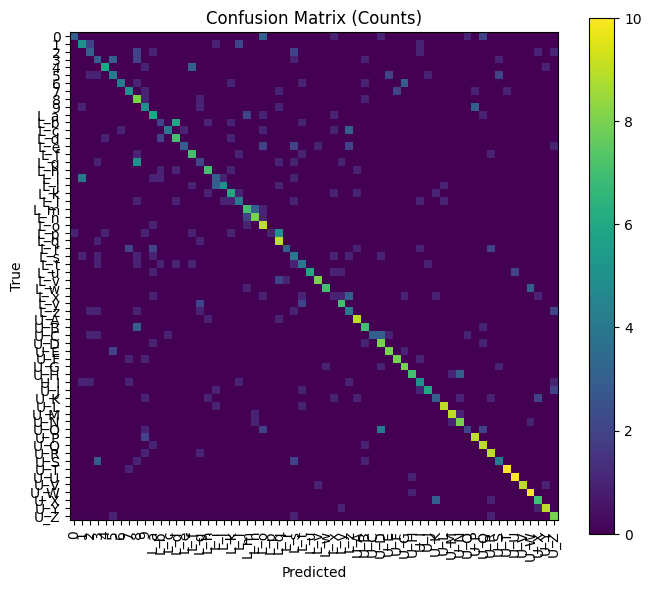

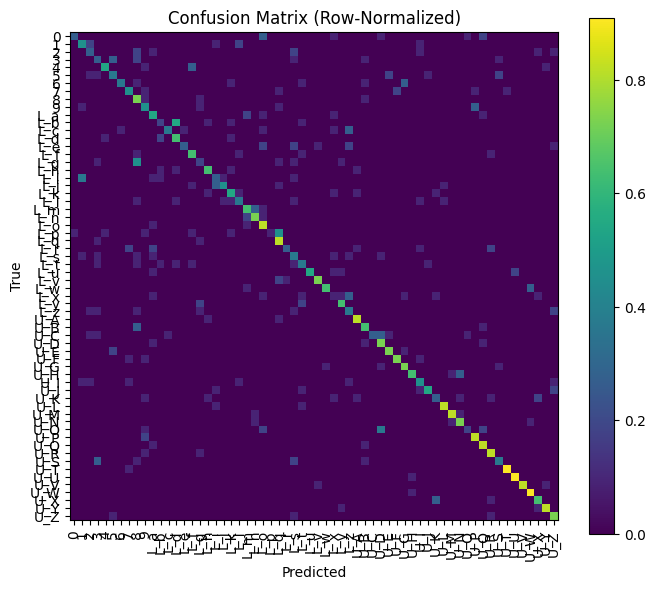

Test Accuracy: 0.5484


In [ ]:
# Evaluation: Precision/Recall/F1 + Confusion Matrix
import numpy as np, sys, itertools
import tensorflow as tf
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt

# 1) Collect predictions & true labels from a tf.data.Dataset
y_true = []
y_pred = []

for batch in test_ds:
    # test_ds should yield (images, labels)
    if isinstance(batch, (tuple, list)) and len(batch) >= 2:
        x, y = batch[0], batch[1]
    else:
        raise ValueError("test_ds must yield (images, labels).")

    # Handle one-hot labels or integer labels
    if len(y.shape) > 1 and y.shape[-1] > 1:
        y_true.extend(np.argmax(y.numpy(), axis=-1))
    else:
        y_true.extend(y.numpy().reshape(-1))

    # Predict class indices
    probs = model.predict(x, verbose=0)
    y_pred.extend(np.argmax(probs, axis=-1))

y_true = np.array(y_true, dtype=int)
y_pred = np.array(y_pred, dtype=int)

# 2) Class names
try:
    class_labels = list(class_names)
except NameError:
    # Fallback if class_names isn't defined
    num_classes = int(max(y_true.max(), y_pred.max()) + 1)
    class_labels = [str(i) for i in range(num_classes)]

# 3) Text report (precision / recall / F1 / support)
print("=== Classification Report ===")
print(classification_report(y_true, y_pred, target_names=class_labels, digits=4))

# 4) Confusion Matrix (counts)
cm = confusion_matrix(y_true, y_pred, labels=range(len(class_labels)))
fig = plt.figure(figsize=(7, 6))
plt.imshow(cm)
plt.title("Confusion Matrix (Counts)")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.xticks(ticks=range(len(class_labels)), labels=class_labels, rotation=90)
plt.yticks(ticks=range(len(class_labels)), labels=class_labels)
plt.colorbar()
plt.tight_layout()
plt.show()

# 5) Confusion Matrix (row-normalized)
with np.errstate(invalid="ignore", divide="ignore"):
    row_sums = cm.sum(axis=1, keepdims=True)
    cm_norm = np.divide(cm, row_sums, out=np.zeros_like(cm, dtype=float), where=row_sums!=0)

fig2 = plt.figure(figsize=(7, 6))
plt.imshow(cm_norm)
plt.title("Confusion Matrix (Row-Normalized)")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.xticks(ticks=range(len(class_labels)), labels=class_labels, rotation=90)
plt.yticks(ticks=range(len(class_labels)), labels=class_labels)
plt.colorbar()
plt.tight_layout()
plt.show()

# 6) Overall accuracy (sanity check)
acc = (y_true == y_pred).mean()
print(f"Test Accuracy: {acc:.4f}")
